# Compare OSC and Unity SOS validation results

This notebook compares: (1) the number of MOI validation results; (2) FLPE validation counts by algorithm; and (3) MOI numerical reproducibility and validation accuracy. It performs an outer join first, so missing/extra records cannot be hidden by a paired inner join.

Place the complete `osc_validation_export` and `unity_validation_export` directories beside this notebook, then run all cells.

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

Python: 3.11.14
NumPy: 2.4.6
pandas: 3.0.3


In [4]:
from pathlib import Path

BASE_DIR = Path("/Users/zhangyushan/Downloads/MOIcheck")

OSC_EXPORT_DIR = BASE_DIR / "osc_validation_export"
UNITY_EXPORT_DIR = BASE_DIR / "unity_validation_export"
OUTPUT_DIR = BASE_DIR / "osc_unity_validation_comparison"

ATOL = 1e-12
RTOL = 1e-10

PRIMARY_METRIC = "nbias"
ACCURACY_TIE_ATOL = 1e-12
MAKE_PLOTS = True

print("OSC export:", OSC_EXPORT_DIR.resolve())
print("Unity export:", UNITY_EXPORT_DIR.resolve())
print("Comparison output:", OUTPUT_DIR.resolve())

print("OSC exists:", OSC_EXPORT_DIR.is_dir())
print("Unity exists:", UNITY_EXPORT_DIR.is_dir())

OSC export: /Users/zhangyushan/Downloads/MOIcheck/osc_validation_export
Unity export: /Users/zhangyushan/Downloads/MOIcheck/unity_validation_export
Comparison output: /Users/zhangyushan/Downloads/MOIcheck/osc_unity_validation_comparison
OSC exists: True
Unity exists: True


## Comparison definitions

- **Counted result:** `has_validation == 1` and finite `nbias`.
- **Numerical reproducibility:** same keyed MOI metric value across runs; both exact float64 and configurable tolerance checks are reported.
- **Validation accuracy:** paired absolute MOI `nBias`; lower is better. This is distinct from machine-level numerical precision.

In [5]:
KEY_COLUMNS = ["partition_key", "reach_id", "gageid_key", "algorithm", "occurrence"]
VALUE_KEY_COLUMNS = KEY_COLUMNS + ["metric"]
STRING_COLUMNS = [
    "partition_key", "reach_id", "gageid_key", "algorithm", "record_key", "metric",
    "value_hex64", "group", "source_file", "relative_path",
]


def read_export(export_dir):
    export_dir = Path(export_dir)
    required = ["validation_cells.csv", "validation_values.csv", "count_summary.csv"]
    missing = [name for name in required if not (export_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Missing files in {export_dir}: {missing}")

    # keep_default_na=False preserves the literal float-hex token "nan".
    cells = pd.read_csv(
        export_dir / "validation_cells.csv", low_memory=False, keep_default_na=False
    )
    values = pd.read_csv(
        export_dir / "validation_values.csv", low_memory=False, keep_default_na=False
    )
    counts = pd.read_csv(
        export_dir / "count_summary.csv", low_memory=False, keep_default_na=False
    )
    for frame in (cells, values):
        for column in STRING_COLUMNS:
            if column in frame:
                frame[column] = frame[column].astype("string").fillna("")
    for frame in (cells, values):
        if "occurrence" in frame:
            frame["occurrence"] = pd.to_numeric(frame["occurrence"], errors="raise").astype(int)
        if "has_validation" in frame:
            frame["has_validation"] = pd.to_numeric(frame["has_validation"], errors="coerce").fillna(0).astype(int)
    values["value"] = pd.to_numeric(values["value"], errors="coerce")
    return {"dir": export_dir, "cells": cells, "values": values, "counts": counts}


def assert_unique(frame, keys, label):
    duplicate = frame.duplicated(keys, keep=False)
    if duplicate.any():
        display(frame.loc[duplicate, keys].head(20))
        raise ValueError(f"{label}: {int(duplicate.sum())} rows have duplicate comparison keys")


def compare_counts(osc_counts, unity_counts):
    index_columns = ["group", "algorithm"]
    value_columns = [
        "total_cells", "validation_flag_count", "finite_nbias_count",
        "result_count", "unique_result_reaches", "unique_result_gages",
    ]
    left = osc_counts[index_columns + value_columns].rename(
        columns={name: f"{name}_osc" for name in value_columns}
    )
    right = unity_counts[index_columns + value_columns].rename(
        columns={name: f"{name}_unity" for name in value_columns}
    )
    compared = left.merge(right, on=index_columns, how="outer", indicator=True)
    for name in value_columns:
        compared[f"{name}_osc"] = compared[f"{name}_osc"].fillna(0).astype(int)
        compared[f"{name}_unity"] = compared[f"{name}_unity"].fillna(0).astype(int)
        compared[f"{name}_delta_unity_minus_osc"] = (
            compared[f"{name}_unity"] - compared[f"{name}_osc"]
        )
    compared["result_count_matches"] = (
        compared["result_count_osc"] == compared["result_count_unity"]
    )
    return compared.sort_values(index_columns).reset_index(drop=True)


def compare_record_coverage(osc_cells, unity_cells):
    osc = osc_cells.loc[osc_cells["has_validation"] == 1].copy()
    unity = unity_cells.loc[unity_cells["has_validation"] == 1].copy()
    assert_unique(osc, ["group"] + KEY_COLUMNS, "OSC validation cells")
    assert_unique(unity, ["group"] + KEY_COLUMNS, "Unity validation cells")
    coverage = osc.merge(
        unity,
        on=["group"] + KEY_COLUMNS,
        how="outer",
        suffixes=("_osc", "_unity"),
        indicator="coverage_status",
    )
    coverage["coverage_status"] = coverage["coverage_status"].map(
        {"both": "both", "left_only": "osc_only", "right_only": "unity_only"}
    ).astype("string")
    return coverage


def compare_moi_values(osc_values, unity_values):
    osc = osc_values.loc[
        (osc_values["group"] == "moi") & (osc_values["has_validation"] == 1)
    ].copy()
    unity = unity_values.loc[
        (unity_values["group"] == "moi") & (unity_values["has_validation"] == 1)
    ].copy()
    assert_unique(osc, VALUE_KEY_COLUMNS, "OSC MOI values")
    assert_unique(unity, VALUE_KEY_COLUMNS, "Unity MOI values")

    keep = VALUE_KEY_COLUMNS + ["value", "value_hex64", "metric_dtype", "is_finite"]
    compared = osc[keep].merge(
        unity[keep],
        on=VALUE_KEY_COLUMNS,
        how="outer",
        suffixes=("_osc", "_unity"),
        indicator="row_status",
    )
    compared["row_status"] = compared["row_status"].map(
        {"both": "both", "left_only": "osc_only", "right_only": "unity_only"}
    ).astype("string")
    matched = compared["row_status"] == "both"
    osc_value = pd.to_numeric(compared["value_osc"], errors="coerce")
    unity_value = pd.to_numeric(compared["value_unity"], errors="coerce")
    compared["value_osc"] = osc_value
    compared["value_unity"] = unity_value
    both_nan = osc_value.isna() & unity_value.isna()
    both_finite = np.isfinite(osc_value) & np.isfinite(unity_value)

    compared["both_finite"] = matched & both_finite
    compared["same_numeric_value"] = matched & ((osc_value == unity_value) | both_nan)
    compared["exact_float64"] = matched & (
        compared["value_hex64_osc"].astype("string")
        == compared["value_hex64_unity"].astype("string")
    )
    compared["within_tolerance"] = False
    compared.loc[matched, "within_tolerance"] = np.isclose(
        osc_value[matched], unity_value[matched], rtol=RTOL, atol=ATOL, equal_nan=True
    )
    compared["delta_unity_minus_osc"] = np.where(
        compared["both_finite"], unity_value - osc_value, np.nan
    )
    compared["absolute_difference"] = np.abs(compared["delta_unity_minus_osc"])
    denominator = np.maximum(np.abs(osc_value), np.abs(unity_value))
    compared["relative_difference"] = np.where(
        compared["both_finite"] & (denominator > 0),
        compared["absolute_difference"] / denominator,
        np.where(compared["both_finite"] & (compared["absolute_difference"] == 0), 0.0, np.nan),
    )
    return compared


def precision_summary(compared):
    rows = []

    def one_summary(frame, metric, algorithm):
        matched = frame.loc[frame["row_status"] == "both"]
        finite = matched.loc[matched["both_finite"]]
        differences = finite["absolute_difference"].dropna()
        return {
            "metric": metric,
            "algorithm": algorithm,
            "union_rows": len(frame),
            "matched_rows": len(matched),
            "osc_only_rows": int((frame["row_status"] == "osc_only").sum()),
            "unity_only_rows": int((frame["row_status"] == "unity_only").sum()),
            "both_finite_rows": len(finite),
            "exact_float64_rows": int(matched["exact_float64"].sum()),
            "same_numeric_value_rows": int(matched["same_numeric_value"].sum()),
            "within_tolerance_rows": int(matched["within_tolerance"].sum()),
            "different_float64_rows": int((~matched["exact_float64"]).sum()),
            "max_absolute_difference": differences.max() if not differences.empty else np.nan,
            "median_absolute_difference": differences.median() if not differences.empty else np.nan,
            "p95_absolute_difference": differences.quantile(0.95) if not differences.empty else np.nan,
            "max_relative_difference": finite["relative_difference"].max() if not finite.empty else np.nan,
        }

    for metric, metric_frame in compared.groupby("metric", sort=True):
        rows.append(one_summary(metric_frame, metric, "ALL"))
        for algorithm, frame in metric_frame.groupby("algorithm", sort=True):
            rows.append(one_summary(frame, metric, algorithm))
    return pd.DataFrame(rows)


def nbias_accuracy_tables(compared):
    paired = compared.loc[
        (compared["metric"] == PRIMARY_METRIC)
        & (compared["row_status"] == "both")
        & compared["both_finite"]
    ].copy()
    paired["abs_nbias_osc"] = paired["value_osc"].abs()
    paired["abs_nbias_unity"] = paired["value_unity"].abs()
    paired["abs_nbias_delta_unity_minus_osc"] = (
        paired["abs_nbias_unity"] - paired["abs_nbias_osc"]
    )
    paired["accuracy_outcome"] = np.select(
        [
            paired["abs_nbias_delta_unity_minus_osc"] < -ACCURACY_TIE_ATOL,
            paired["abs_nbias_delta_unity_minus_osc"] > ACCURACY_TIE_ATOL,
        ],
        ["unity_better", "osc_better"],
        default="tie",
    )

    rows = []
    def summarize(frame, algorithm):
        delta = frame["abs_nbias_delta_unity_minus_osc"]
        return {
            "metric": PRIMARY_METRIC,
            "algorithm": algorithm,
            "paired_samples": len(frame),
            "median_abs_nbias_osc": frame["abs_nbias_osc"].median(),
            "median_abs_nbias_unity": frame["abs_nbias_unity"].median(),
            "mean_abs_nbias_osc": frame["abs_nbias_osc"].mean(),
            "mean_abs_nbias_unity": frame["abs_nbias_unity"].mean(),
            "p90_abs_nbias_osc": frame["abs_nbias_osc"].quantile(0.90),
            "p90_abs_nbias_unity": frame["abs_nbias_unity"].quantile(0.90),
            "median_paired_abs_nbias_delta_unity_minus_osc": delta.median(),
            "mean_paired_abs_nbias_delta_unity_minus_osc": delta.mean(),
            "unity_better_count": int((frame["accuracy_outcome"] == "unity_better").sum()),
            "osc_better_count": int((frame["accuracy_outcome"] == "osc_better").sum()),
            "tie_count": int((frame["accuracy_outcome"] == "tie").sum()),
        }

    if not paired.empty:
        rows.append(summarize(paired, "ALL"))
        for algorithm, frame in paired.groupby("algorithm", sort=True):
            rows.append(summarize(frame, algorithm))
    return paired, pd.DataFrame(rows)

## Run comparisons and export detailed CSV files

In [6]:
for directory, label in ((OSC_EXPORT_DIR, "OSC"), (UNITY_EXPORT_DIR, "Unity")):
    if not directory.is_dir():
        raise NotADirectoryError(f"{label} export directory not found: {directory.resolve()}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
osc = read_export(OSC_EXPORT_DIR)
unity = read_export(UNITY_EXPORT_DIR)

count_comparison = compare_counts(osc["counts"], unity["counts"])
record_coverage = compare_record_coverage(osc["cells"], unity["cells"])
moi_differences = compare_moi_values(osc["values"], unity["values"])
moi_precision = precision_summary(moi_differences)
moi_nbias_paired, moi_accuracy = nbias_accuracy_tables(moi_differences)

csv_options = {"index": False, "float_format": "%.17g", "na_rep": "NaN"}
count_comparison.to_csv(OUTPUT_DIR / "count_comparison.csv", **csv_options)
record_coverage.to_csv(OUTPUT_DIR / "record_coverage.csv", **csv_options)
moi_differences.to_csv(OUTPUT_DIR / "moi_value_differences.csv", **csv_options)
moi_precision.to_csv(OUTPUT_DIR / "moi_precision_summary.csv", **csv_options)
moi_nbias_paired.to_csv(OUTPUT_DIR / "moi_nbias_pairwise.csv", **csv_options)
moi_accuracy.to_csv(OUTPUT_DIR / "moi_accuracy_summary.csv", **csv_options)

print("\n=== 1) validation MOI / FLPE result counts ===")
display(
    count_comparison.loc[
        :, [
            "group", "algorithm", "result_count_osc", "result_count_unity",
            "result_count_delta_unity_minus_osc", "result_count_matches", "_merge",
        ]
    ]
)

print("\n=== 2) Record-key coverage ===")
coverage_summary = (
    record_coverage.groupby(["group", "coverage_status"], observed=True)
    .size().rename("rows").reset_index()
)
display(coverage_summary)

print("\n=== 3) MOI numeric reproducibility (exact and tolerance-aware) ===")
display(moi_precision.loc[moi_precision["algorithm"] == "ALL"].reset_index(drop=True))

print("\n=== 4) MOI validation accuracy based on paired |nBias| (lower is better) ===")
if moi_accuracy.empty:
    print(f"No common finite {PRIMARY_METRIC!r} samples were available.")
else:
    display(moi_accuracy)

count_mismatches = int((~count_comparison["result_count_matches"]).sum())
coverage_mismatches = int((record_coverage["coverage_status"] != "both").sum())
matched_precision = moi_precision.loc[moi_precision["algorithm"] == "ALL"]
numeric_differences = int(matched_precision["different_float64_rows"].sum())
tolerance_failures = int(
    (matched_precision["matched_rows"] - matched_precision["within_tolerance_rows"]).sum()
)

print("\n=== Automatic conclusion ===")
print("Count comparison:", "MATCH" if count_mismatches == 0 else f"DIFFER ({count_mismatches} rows)")
print("Record coverage:", "MATCH" if coverage_mismatches == 0 else f"DIFFER ({coverage_mismatches} records)")
print("MOI exact float64 values:", "MATCH" if numeric_differences == 0 else f"DIFFER ({numeric_differences} matched values)")
print(
    f"MOI values within atol={ATOL:g}, rtol={RTOL:g}:",
    "YES" if tolerance_failures == 0 else f"NO ({tolerance_failures} matched values outside tolerance)",
)
print(f"\nAll comparison CSV files: {OUTPUT_DIR.resolve()}")


=== 1) validation MOI / FLPE result counts ===


,group,algorithm,result_count_osc,result_count_unity,result_count_delta_unity_minus_osc,result_count_matches,_merge
0,flpe,ALL,6649,1433,-5216,False,both
1,flpe,busboi,921,283,-638,False,both
2,flpe,consensus,1640,0,-1640,False,both
3,flpe,hivdi,0,0,0,True,both
4,flpe,metroman,1089,271,-818,False,both
5,flpe,momma,1341,407,-934,False,both
6,flpe,sad,0,0,0,True,both
7,flpe,sic4dvar,1658,472,-1186,False,both
8,moi,ALL,3467,1829,-1638,False,both
9,moi,busboi,506,268,-238,False,both



=== 2) Record-key coverage ===


,group,coverage_status,rows
0,flpe,both,3220
1,flpe,osc_only,13174
2,flpe,unity_only,490
3,moi,both,756
4,moi,osc_only,3612
5,moi,unity_only,1463



=== 3) MOI numeric reproducibility (exact and tolerance-aware) ===


,metric,algorithm,union_rows,matched_rows,osc_only_rows,unity_only_rows,both_finite_rows,exact_float64_rows,same_numeric_value_rows,within_tolerance_rows,different_float64_rows,max_absolute_difference,median_absolute_difference,p95_absolute_difference,max_relative_difference
0,nbias,ALL,5831,756,3612,1463,566,128,128,128,628,29.667762,0.120207,2.016319,1.991481



=== 4) MOI validation accuracy based on paired |nBias| (lower is better) ===


,metric,algorithm,paired_samples,median_abs_nbias_osc,median_abs_nbias_unity,mean_abs_nbias_osc,mean_abs_nbias_unity,p90_abs_nbias_osc,p90_abs_nbias_unity,median_paired_abs_nbias_delta_unity_minus_osc,mean_paired_abs_nbias_delta_unity_minus_osc,unity_better_count,osc_better_count,tie_count
0,nbias,ALL,566,0.318311,0.295364,0.823879,0.865328,1.705063,1.218934,-0.009270,0.041449,304,262,0
1,nbias,busboi,84,0.324421,0.279406,0.701686,0.786186,1.338137,1.271083,-0.012419,0.084500,46,38,0
2,nbias,consensus,84,0.298053,0.328100,0.823936,0.800585,1.424540,1.156229,-0.012823,-0.023351,45,39,0
3,nbias,hivdi,84,0.255881,0.360930,0.914541,1.237087,1.857702,1.891995,0.016963,0.322546,36,48,0
4,nbias,metroman,84,0.343793,0.256016,0.790631,0.804894,1.989100,1.082631,-0.036320,0.014263,49,35,0
5,nbias,momma,62,0.284120,0.303166,0.938338,0.678935,1.363105,0.980684,-0.000424,-0.259403,32,30,0
6,nbias,sad,84,0.292361,0.326236,0.915841,1.059672,1.831721,1.707817,0.006091,0.143831,39,45,0
7,nbias,sic4dvar,84,0.347684,0.276826,0.712155,0.641121,1.616559,0.991010,-0.067104,-0.071034,57,27,0



=== Automatic conclusion ===
Count comparison: DIFFER (14 rows)
Record coverage: DIFFER (18739 records)
MOI exact float64 values: DIFFER (628 matched values)
MOI values within atol=1e-12, rtol=1e-10: NO (628 matched values outside tolerance)

All comparison CSV files: /Users/zhangyushan/Downloads/MOIcheck/osc_unity_validation_comparison


## Diagnostic plots

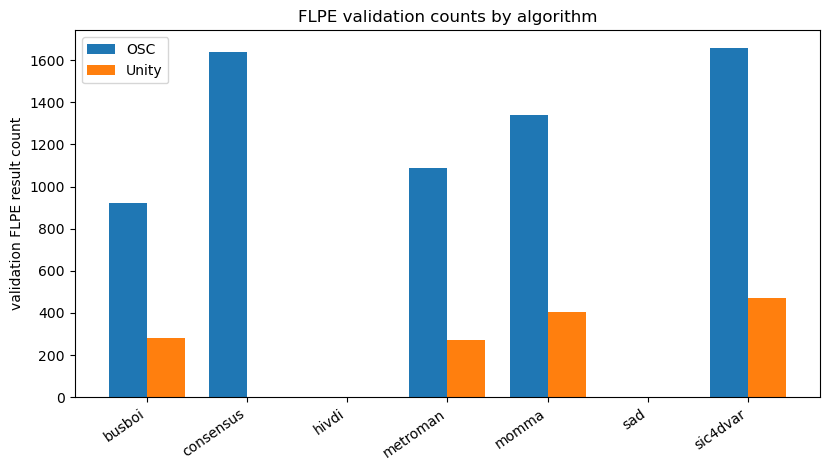

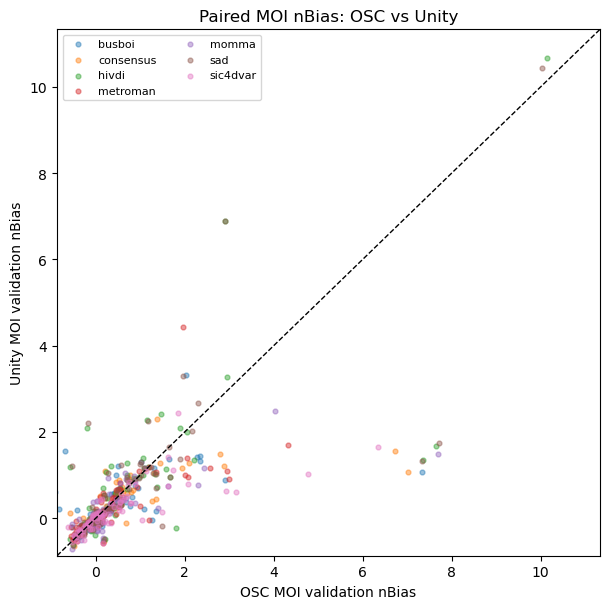

In [7]:
if MAKE_PLOTS:
    import matplotlib.pyplot as plt

    flpe_counts = count_comparison.loc[
        (count_comparison["group"] == "flpe") & (count_comparison["algorithm"] != "ALL")
    ].copy()
    if not flpe_counts.empty:
        x = np.arange(len(flpe_counts))
        width = 0.38
        fig, ax = plt.subplots(figsize=(max(8, len(flpe_counts) * 1.2), 4.8))
        ax.bar(x - width / 2, flpe_counts["result_count_osc"], width, label="OSC")
        ax.bar(x + width / 2, flpe_counts["result_count_unity"], width, label="Unity")
        ax.set_xticks(x, flpe_counts["algorithm"], rotation=35, ha="right")
        ax.set_ylabel("validation FLPE result count")
        ax.set_title("FLPE validation counts by algorithm")
        ax.legend()
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / "flpe_count_comparison.png", dpi=180)
        plt.show()

    if not moi_nbias_paired.empty:
        fig, ax = plt.subplots(figsize=(6.2, 6.2))
        for algorithm, frame in moi_nbias_paired.groupby("algorithm", sort=True):
            ax.scatter(frame["value_osc"], frame["value_unity"], s=12, alpha=0.45, label=algorithm)
        finite_values = np.concatenate(
            [moi_nbias_paired["value_osc"].to_numpy(), moi_nbias_paired["value_unity"].to_numpy()]
        )
        lower, upper = np.nanpercentile(finite_values, [1, 99])
        if np.isfinite(lower) and np.isfinite(upper):
            ax.plot([lower, upper], [lower, upper], color="black", linestyle="--", linewidth=1)
            ax.set_xlim(lower, upper)
            ax.set_ylim(lower, upper)
        ax.set_xlabel("OSC MOI validation nBias")
        ax.set_ylabel("Unity MOI validation nBias")
        ax.set_title("Paired MOI nBias: OSC vs Unity")
        ax.legend(fontsize=8, ncol=2)
        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / "moi_nbias_scatter.png", dpi=180)
        plt.show()

## How to interpret

Start with `count_comparison.csv`. If counts match, inspect `record_coverage.csv` to ensure the actual reach/gage/algorithm keys also match. Then use `moi_precision_summary.csv` for numerical equality and `moi_accuracy_summary.csv` for paired validation performance. `moi_value_differences.csv` contains every metric-level difference.

In [8]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE_DIR = Path("/Users/zhangyushan/Downloads/MOIcheck")

OSC_EXPORT_DIR = BASE_DIR / "osc_validation_export"
UNITY_EXPORT_DIR = BASE_DIR / "unity_validation_export"

CALVAL_CSV = Path(
    "/Users/zhangyushan/GithubCodes/MOI_gage_correlation/"
    "CalValSeparation_basin_stratified_v2.csv"
)

OUTPUT_DIR = BASE_DIR / "osc_unity_validation_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for path in (
    OSC_EXPORT_DIR / "validation_cells.csv",
    UNITY_EXPORT_DIR / "validation_cells.csv",
    OSC_EXPORT_DIR / "validation_values.csv",
    UNITY_EXPORT_DIR / "validation_values.csv",
    CALVAL_CSV,
):
    if not path.is_file():
        raise FileNotFoundError(path)

print("OSC export:", OSC_EXPORT_DIR)
print("Unity export:", UNITY_EXPORT_DIR)
print("CalVal CSV:", CALVAL_CSV)
print("Output:", OUTPUT_DIR)

OSC export: /Users/zhangyushan/Downloads/MOIcheck/osc_validation_export
Unity export: /Users/zhangyushan/Downloads/MOIcheck/unity_validation_export
CalVal CSV: /Users/zhangyushan/GithubCodes/MOI_gage_correlation/CalValSeparation_basin_stratified_v2.csv
Output: /Users/zhangyushan/Downloads/MOIcheck/osc_unity_validation_comparison


In [9]:
def normalize_reach_series(series):
    """Normalize integer/float/string reach IDs without scientific notation."""
    text = series.astype("string").str.strip()
    numeric = pd.to_numeric(text, errors="coerce")

    result = text.copy()
    numeric_mask = numeric.notna()
    result.loc[numeric_mask] = (
        numeric.loc[numeric_mask]
        .round()
        .astype("Int64")
        .astype("string")
    )
    return result.fillna("")


def parse_bool_series(series):
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes"})
    )


calval = pd.read_csv(
    CALVAL_CSV,
    dtype={
        "reach_id_v17b": "string",
        "station_id": "string",
        "group": "string",
    },
)

calval["reach_id"] = normalize_reach_series(calval["reach_id_v17b"])
calval["calval_group"] = calval["group"].str.strip().str.lower()

# Make sure one reach is not assigned conflicting groups.
group_conflicts = (
    calval.groupby("reach_id")["calval_group"]
    .nunique()
    .loc[lambda values: values > 1]
)

if not group_conflicts.empty:
    raise ValueError(
        "Some reaches have conflicting groups in the CalVal CSV:\n"
        f"{group_conflicts.head(20)}"
    )

calval_lookup = (
    calval[["reach_id", "calval_group"]]
    .drop_duplicates("reach_id")
    .set_index("reach_id")["calval_group"]
)

csv_validation_reaches = set(
    calval.loc[
        calval["calval_group"] == "validation",
        "reach_id",
    ]
)

print(
    f"CalVal CSV: {len(calval):,} rows; "
    f"{len(csv_validation_reaches):,} unique validation reaches"
)


def load_moi_cells(export_dir, run_label):
    path = export_dir / "validation_cells.csv"

    frame = pd.read_csv(
        path,
        dtype={
            "group": "string",
            "reach_id": "string",
            "gageid": "string",
            "gageid_key": "string",
            "algorithm": "string",
            "source_file": "string",
        },
        keep_default_na=False,
        low_memory=False,
    )

    frame["reach_id"] = normalize_reach_series(frame["reach_id"])
    frame["has_validation"] = (
        pd.to_numeric(frame["has_validation"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
    frame["result_present"] = parse_bool_series(frame["result_present"])

    frame = frame.loc[
        (frame["group"].str.lower() == "moi")
        & (frame["has_validation"] == 1)
    ].copy()

    frame["run"] = run_label
    frame["calval_group"] = (
        frame["reach_id"]
        .map(calval_lookup)
        .fillna("not_in_csv")
    )
    frame["is_csv_validation"] = (
        frame["calval_group"] == "validation"
    )
    return frame


osc_cells = load_moi_cells(OSC_EXPORT_DIR, "OSC")
unity_cells = load_moi_cells(UNITY_EXPORT_DIR, "Unity")


def build_membership_summary(frame):
    rows = []

    scopes = {
        "has_validation == 1": frame,
        "finite MOI nBias result": frame.loc[
            frame["result_present"]
        ],
    }

    for scope_name, scope in scopes.items():
        reach_table = scope[
            ["reach_id", "calval_group"]
        ].drop_duplicates()

        cell_counts = scope["calval_group"].value_counts()
        reach_counts = reach_table["calval_group"].value_counts()

        categories = sorted(
            set(cell_counts.index).union(reach_counts.index)
        )

        for category in categories:
            rows.append(
                {
                    "run": frame["run"].iloc[0],
                    "scope": scope_name,
                    "calval_group": category,
                    "result_cells": int(cell_counts.get(category, 0)),
                    "unique_reaches": int(reach_counts.get(category, 0)),
                }
            )

    return pd.DataFrame(rows)


membership_summary = pd.concat(
    [
        build_membership_summary(osc_cells),
        build_membership_summary(unity_cells),
    ],
    ignore_index=True,
)

display(membership_summary)

membership_summary.to_csv(
    OUTPUT_DIR / "moi_reach_calval_membership_summary.csv",
    index=False,
)


def nonvalidation_result_details(frame):
    nonvalidation = frame.loc[
        frame["result_present"]
        & (frame["calval_group"] != "validation")
    ].copy()

    if nonvalidation.empty:
        return pd.DataFrame(
            columns=[
                "run",
                "reach_id",
                "calval_group",
                "gageids",
                "algorithms",
                "result_cells",
            ]
        )

    return (
        nonvalidation.groupby(
            ["run", "reach_id", "calval_group"],
            as_index=False,
        )
        .agg(
            gageids=(
                "gageid",
                lambda values: "|".join(
                    sorted({str(value) for value in values if str(value)})
                ),
            ),
            algorithms=(
                "algorithm",
                lambda values: "|".join(sorted(set(values))),
            ),
            result_cells=("algorithm", "size"),
        )
        .sort_values(["calval_group", "reach_id"])
        .reset_index(drop=True)
    )


osc_nonvalidation = nonvalidation_result_details(osc_cells)
unity_nonvalidation = nonvalidation_result_details(unity_cells)

osc_nonvalidation.to_csv(
    OUTPUT_DIR / "osc_moi_results_not_csv_validation.csv",
    index=False,
)
unity_nonvalidation.to_csv(
    OUTPUT_DIR / "unity_moi_results_not_csv_validation.csv",
    index=False,
)

print("\nOSC finite MOI results outside CSV validation:")
display(osc_nonvalidation.head(20))

print("\nUnity finite MOI results outside CSV validation:")
display(unity_nonvalidation.head(20))

for label, frame in (
    ("OSC", osc_cells),
    ("Unity", unity_cells),
):
    finite_reaches = frame.loc[
        frame["result_present"],
        ["reach_id", "calval_group"],
    ].drop_duplicates()

    all_valid = finite_reaches["calval_group"].eq(
        "validation"
    ).all()

    print(
        f"{label}: all finite-result reaches are CSV validation? "
        f"{all_valid}"
    )

CalVal CSV: 3,642 rows; 743 unique validation reaches


,run,scope,calval_group,result_cells,unique_reaches
0,OSC,has_validation == 1,calibration,3535,505
1,OSC,has_validation == 1,excluded_insufficient_observations,7,1
2,OSC,has_validation == 1,validation,826,118
3,OSC,finite MOI nBias result,calibration,2808,410
4,OSC,finite MOI nBias result,validation,659,96
5,Unity,has_validation == 1,excluded_insufficient_observations,35,5
6,Unity,has_validation == 1,validation,2184,312
7,Unity,finite MOI nBias result,excluded_insufficient_observations,7,1
8,Unity,finite MOI nBias result,validation,1822,267



OSC finite MOI results outside CSV validation:


,run,reach_id,calval_group,gageids,algorithms,result_cells
0,OSC,12291300071,calibration,1001,busboi|consensus|hivdi|metroman|momma|sad|sic4...,7
1,OSC,12440500161,calibration,2224,busboi|consensus|hivdi|metroman|sad|sic4dvar,6
2,OSC,12540400191,calibration,3274,busboi|consensus|hivdi|metroman|momma|sad|sic4...,7
3,OSC,12551000531,calibration,3224,busboi|consensus|hivdi|metroman|momma|sad|sic4...,7
4,OSC,12552000061,calibration,852,busboi|consensus|hivdi|metroman|momma|sad|sic4...,7
5,OSC,12730300081,calibration,2537,busboi|consensus|hivdi|metroman|sad|sic4dvar,6
6,OSC,12770100021,calibration,2529,busboi|consensus|hivdi|metroman|sad|sic4dvar,6
7,OSC,12770100201,calibration,2516,busboi|consensus|hivdi|metroman|momma|sad|sic4...,7
8,OSC,12797100151,calibration,2318,busboi|consensus|hivdi|metroman|momma|sad|sic4...,7
9,OSC,12797900191,calibration,2354,busboi|consensus|hivdi|metroman|momma|sad|sic4...,7



Unity finite MOI results outside CSV validation:


,run,reach_id,calval_group,gageids,algorithms,result_cells
0,Unity,23216000101,excluded_insufficient_observations,1756,busboi|consensus|hivdi|metroman|momma|sad|sic4...,7


OSC: all finite-result reaches are CSV validation? False
Unity: all finite-result reaches are CSV validation? False


In [10]:
def load_moi_nbias(export_dir, run_label):
    path = export_dir / "validation_values.csv"

    frame = pd.read_csv(
        path,
        dtype={
            "group": "string",
            "metric": "string",
            "reach_id": "string",
            "gageid_key": "string",
            "algorithm": "string",
            "source_file": "string",
        },
        keep_default_na=False,
        low_memory=False,
    )

    frame["reach_id"] = normalize_reach_series(frame["reach_id"])
    frame["has_validation"] = (
        pd.to_numeric(frame["has_validation"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
    frame["value"] = pd.to_numeric(
        frame["value"],
        errors="coerce",
    )

    frame = frame.loc[
        (frame["group"].str.lower() == "moi")
        & (frame["metric"].str.lower() == "nbias")
        & (frame["has_validation"] == 1)
        & np.isfinite(frame["value"])
    ].copy()

    frame["run"] = run_label
    frame["calval_group"] = (
        frame["reach_id"]
        .map(calval_lookup)
        .fillna("not_in_csv")
    )
    frame["abs_nbias"] = frame["value"].abs()

    return frame


osc_nbias_all = load_moi_nbias(
    OSC_EXPORT_DIR,
    "OSC",
)
unity_nbias_all = load_moi_nbias(
    UNITY_EXPORT_DIR,
    "Unity",
)

# Strictly retain only reaches labeled validation in the supplied CSV.
osc_nbias = osc_nbias_all.loc[
    osc_nbias_all["calval_group"] == "validation"
].copy()

unity_nbias = unity_nbias_all.loc[
    unity_nbias_all["calval_group"] == "validation"
].copy()


coverage = pd.DataFrame(
    [
        {
            "run": "OSC",
            "all_finite_moi_cells": len(osc_nbias_all),
            "csv_validation_moi_cells": len(osc_nbias),
            "all_finite_reaches": osc_nbias_all["reach_id"].nunique(),
            "csv_validation_reaches": osc_nbias["reach_id"].nunique(),
        },
        {
            "run": "Unity",
            "all_finite_moi_cells": len(unity_nbias_all),
            "csv_validation_moi_cells": len(unity_nbias),
            "all_finite_reaches": unity_nbias_all["reach_id"].nunique(),
            "csv_validation_reaches": unity_nbias["reach_id"].nunique(),
        },
    ]
)

display(coverage)
coverage.to_csv(
    OUTPUT_DIR / "moi_csv_validation_coverage.csv",
    index=False,
)


def summarize_unpaired_accuracy(frame):
    rows = []

    groups = [("ALL", frame)]
    groups.extend(list(frame.groupby("algorithm", sort=True)))

    for algorithm, data in groups:
        values = data["abs_nbias"].dropna()

        rows.append(
            {
                "run": data["run"].iloc[0],
                "algorithm": algorithm,
                "samples": len(values),
                "unique_reaches": data["reach_id"].nunique(),
                "median_abs_nbias": values.median(),
                "mean_abs_nbias": values.mean(),
                "p90_abs_nbias": values.quantile(0.90),
                "p95_abs_nbias": values.quantile(0.95),
                "fraction_within_10pct": (values <= 0.10).mean(),
                "fraction_within_20pct": (values <= 0.20).mean(),
                "fraction_within_50pct": (values <= 0.50).mean(),
            }
        )

    return pd.DataFrame(rows)


unpaired_accuracy = pd.concat(
    [
        summarize_unpaired_accuracy(osc_nbias),
        summarize_unpaired_accuracy(unity_nbias),
    ],
    ignore_index=True,
)

print("Accuracy on each run's available CSV-validation reaches:")
display(unpaired_accuracy)

unpaired_accuracy.to_csv(
    OUTPUT_DIR / "moi_accuracy_unpaired_csv_validation.csv",
    index=False,
    float_format="%.17g",
)

,run,all_finite_moi_cells,csv_validation_moi_cells,all_finite_reaches,csv_validation_reaches
0,OSC,3467,659,506,96
1,Unity,1829,1822,268,267


Accuracy on each run's available CSV-validation reaches:


,run,algorithm,samples,unique_reaches,median_abs_nbias,mean_abs_nbias,p90_abs_nbias,p95_abs_nbias,fraction_within_10pct,fraction_within_20pct,fraction_within_50pct
0,OSC,ALL,659,96,0.300464,0.841622,1.954338,3.011603,0.213961,0.397572,0.663126
1,OSC,busboi,96,96,0.300755,0.753351,1.838309,2.602629,0.218750,0.395833,0.708333
2,OSC,consensus,96,96,0.280872,0.828370,2.019706,3.085931,0.229167,0.385417,0.666667
3,OSC,hivdi,96,96,0.249408,0.969486,2.134565,5.148822,0.250000,0.416667,0.635417
4,OSC,metroman,96,96,0.338420,0.756405,1.751203,2.659905,0.166667,0.385417,0.697917
5,OSC,momma,83,83,0.310143,0.934164,1.586764,2.766949,0.204819,0.433735,0.674699
6,OSC,sad,96,96,0.267124,0.948699,2.060054,5.104569,0.250000,0.416667,0.635417
7,OSC,sic4dvar,96,96,0.314634,0.713410,1.644060,2.982907,0.177083,0.354167,0.625000
8,Unity,ALL,1822,267,0.283840,3.260943,1.468988,4.296544,0.214599,0.397366,0.689352
9,Unity,busboi,267,267,0.259362,0.959369,1.313234,2.664662,0.224719,0.400749,0.704120


In [11]:
PAIR_KEYS = ["reach_id", "algorithm"]
PAIR_TIE_ATOL = 1e-12


def assert_unique_pair_keys(frame, label):
    duplicate = frame.duplicated(PAIR_KEYS, keep=False)

    if duplicate.any():
        display(
            frame.loc[
                duplicate,
                PAIR_KEYS + ["gageid_key", "value"],
            ].sort_values(PAIR_KEYS).head(30)
        )
        raise ValueError(
            f"{label} has {int(duplicate.sum())} duplicated "
            "reach-algorithm rows"
        )


assert_unique_pair_keys(osc_nbias, "OSC")
assert_unique_pair_keys(unity_nbias, "Unity")

osc_pair_source = osc_nbias[
    PAIR_KEYS + ["gageid_key", "value"]
].rename(
    columns={
        "gageid_key": "gageid_key_osc",
        "value": "nbias_osc",
    }
)

unity_pair_source = unity_nbias[
    PAIR_KEYS + ["gageid_key", "value"]
].rename(
    columns={
        "gageid_key": "gageid_key_unity",
        "value": "nbias_unity",
    }
)

paired = osc_pair_source.merge(
    unity_pair_source,
    on=PAIR_KEYS,
    how="inner",
    validate="one_to_one",
)

if paired.empty:
    raise ValueError(
        "No common CSV-validation reach-algorithm samples found"
    )

paired["gageid_matches"] = (
    paired["gageid_key_osc"]
    == paired["gageid_key_unity"]
)

if not paired["gageid_matches"].all():
    print("Warning: some paired reaches have different gage IDs")
    display(
        paired.loc[
            ~paired["gageid_matches"],
            PAIR_KEYS
            + ["gageid_key_osc", "gageid_key_unity"],
        ].head(20)
    )

paired["abs_nbias_osc"] = paired["nbias_osc"].abs()
paired["abs_nbias_unity"] = paired["nbias_unity"].abs()

# Negative means Unity has lower |nBias| and is therefore better.
paired["abs_nbias_delta_unity_minus_osc"] = (
    paired["abs_nbias_unity"]
    - paired["abs_nbias_osc"]
)

paired["accuracy_outcome"] = np.select(
    [
        paired["abs_nbias_delta_unity_minus_osc"]
        < -PAIR_TIE_ATOL,
        paired["abs_nbias_delta_unity_minus_osc"]
        > PAIR_TIE_ATOL,
    ],
    ["unity_better", "osc_better"],
    default="tie",
)


def summarize_paired_accuracy(frame, algorithm):
    delta = frame["abs_nbias_delta_unity_minus_osc"]

    return {
        "algorithm": algorithm,
        "paired_samples": len(frame),
        "unique_reaches": frame["reach_id"].nunique(),
        "median_abs_nbias_osc": frame["abs_nbias_osc"].median(),
        "median_abs_nbias_unity": frame["abs_nbias_unity"].median(),
        "mean_abs_nbias_osc": frame["abs_nbias_osc"].mean(),
        "mean_abs_nbias_unity": frame["abs_nbias_unity"].mean(),
        "p90_abs_nbias_osc": frame["abs_nbias_osc"].quantile(0.90),
        "p90_abs_nbias_unity": frame["abs_nbias_unity"].quantile(0.90),
        "p95_abs_nbias_osc": frame["abs_nbias_osc"].quantile(0.95),
        "p95_abs_nbias_unity": frame["abs_nbias_unity"].quantile(0.95),
        "median_delta_unity_minus_osc": delta.median(),
        "mean_delta_unity_minus_osc": delta.mean(),
        "unity_better_count": int(
            (frame["accuracy_outcome"] == "unity_better").sum()
        ),
        "osc_better_count": int(
            (frame["accuracy_outcome"] == "osc_better").sum()
        ),
        "tie_count": int(
            (frame["accuracy_outcome"] == "tie").sum()
        ),
        "unity_better_fraction": (
            frame["accuracy_outcome"] == "unity_better"
        ).mean(),
    }


paired_summary_rows = [
    summarize_paired_accuracy(paired, "ALL")
]

for algorithm, data in paired.groupby(
    "algorithm",
    sort=True,
):
    paired_summary_rows.append(
        summarize_paired_accuracy(data, algorithm)
    )

paired_accuracy = pd.DataFrame(paired_summary_rows)

print(
    f"Common CSV-validation reaches: "
    f"{paired['reach_id'].nunique():,}"
)
print(
    f"Common reach-algorithm samples: {len(paired):,}"
)

display(paired_accuracy)

paired.to_csv(
    OUTPUT_DIR / "moi_nbias_paired_csv_validation.csv",
    index=False,
    float_format="%.17g",
)

paired_accuracy.to_csv(
    OUTPUT_DIR / "moi_accuracy_paired_csv_validation.csv",
    index=False,
    float_format="%.17g",
)

Common CSV-validation reaches: 84
Common reach-algorithm samples: 566


,algorithm,paired_samples,unique_reaches,median_abs_nbias_osc,median_abs_nbias_unity,mean_abs_nbias_osc,mean_abs_nbias_unity,p90_abs_nbias_osc,p90_abs_nbias_unity,p95_abs_nbias_osc,p95_abs_nbias_unity,median_delta_unity_minus_osc,mean_delta_unity_minus_osc,unity_better_count,osc_better_count,tie_count,unity_better_fraction
0,ALL,566,84,0.318311,0.295364,0.823879,0.865328,1.705063,1.218934,2.899683,2.003514,-0.009270,0.041449,304,262,0,0.537102
1,busboi,84,84,0.324421,0.279406,0.701686,0.786186,1.338137,1.271083,2.322664,1.434019,-0.012419,0.084500,46,38,0,0.547619
2,consensus,84,84,0.298053,0.328100,0.823936,0.800585,1.424540,1.156229,2.872979,1.450331,-0.012823,-0.023351,45,39,0,0.535714
3,hivdi,84,84,0.255881,0.360930,0.914541,1.237087,1.857702,1.891995,2.940905,2.393737,0.016963,0.322546,36,48,0,0.428571
4,metroman,84,84,0.343793,0.256016,0.790631,0.804894,1.989100,1.082631,2.897399,1.354082,-0.036320,0.014263,49,35,0,0.583333
5,momma,62,62,0.284120,0.303166,0.938338,0.678935,1.363105,0.980684,2.429450,1.167515,-0.000424,-0.259403,32,30,0,0.516129
6,sad,84,84,0.292361,0.326236,0.915841,1.059672,1.831721,1.707817,2.806973,2.602278,0.006091,0.143831,39,45,0,0.464286
7,sic4dvar,84,84,0.347684,0.276826,0.712155,0.641121,1.616559,0.991010,2.798076,1.119953,-0.067104,-0.071034,57,27,0,0.678571


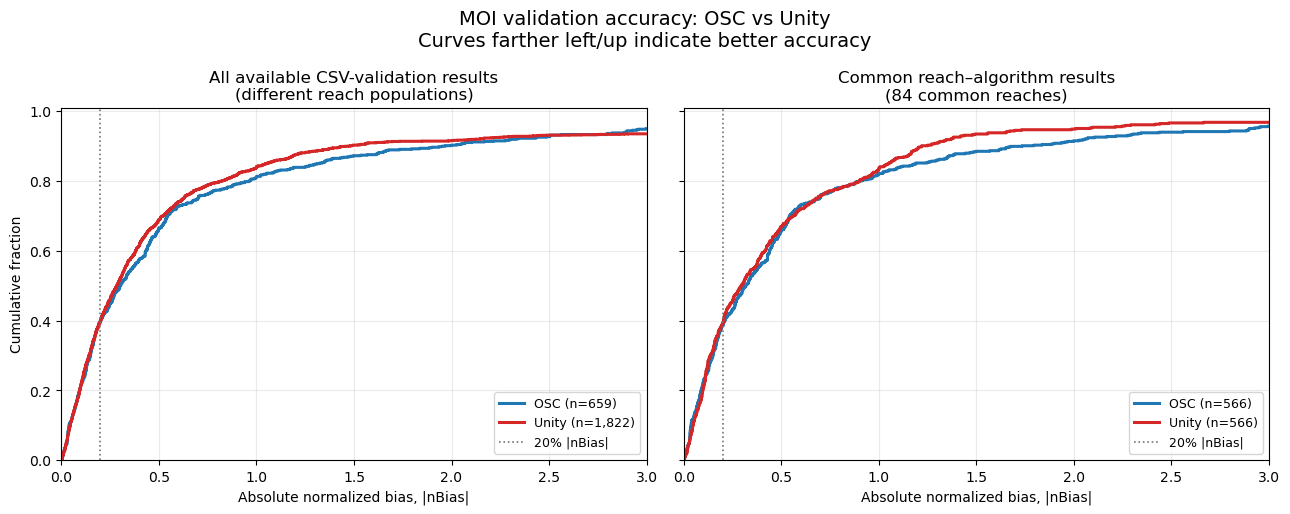

Saved: /Users/zhangyushan/Downloads/MOIcheck/osc_unity_validation_comparison/moi_abs_nbias_ecdf_all_vs_paired.png


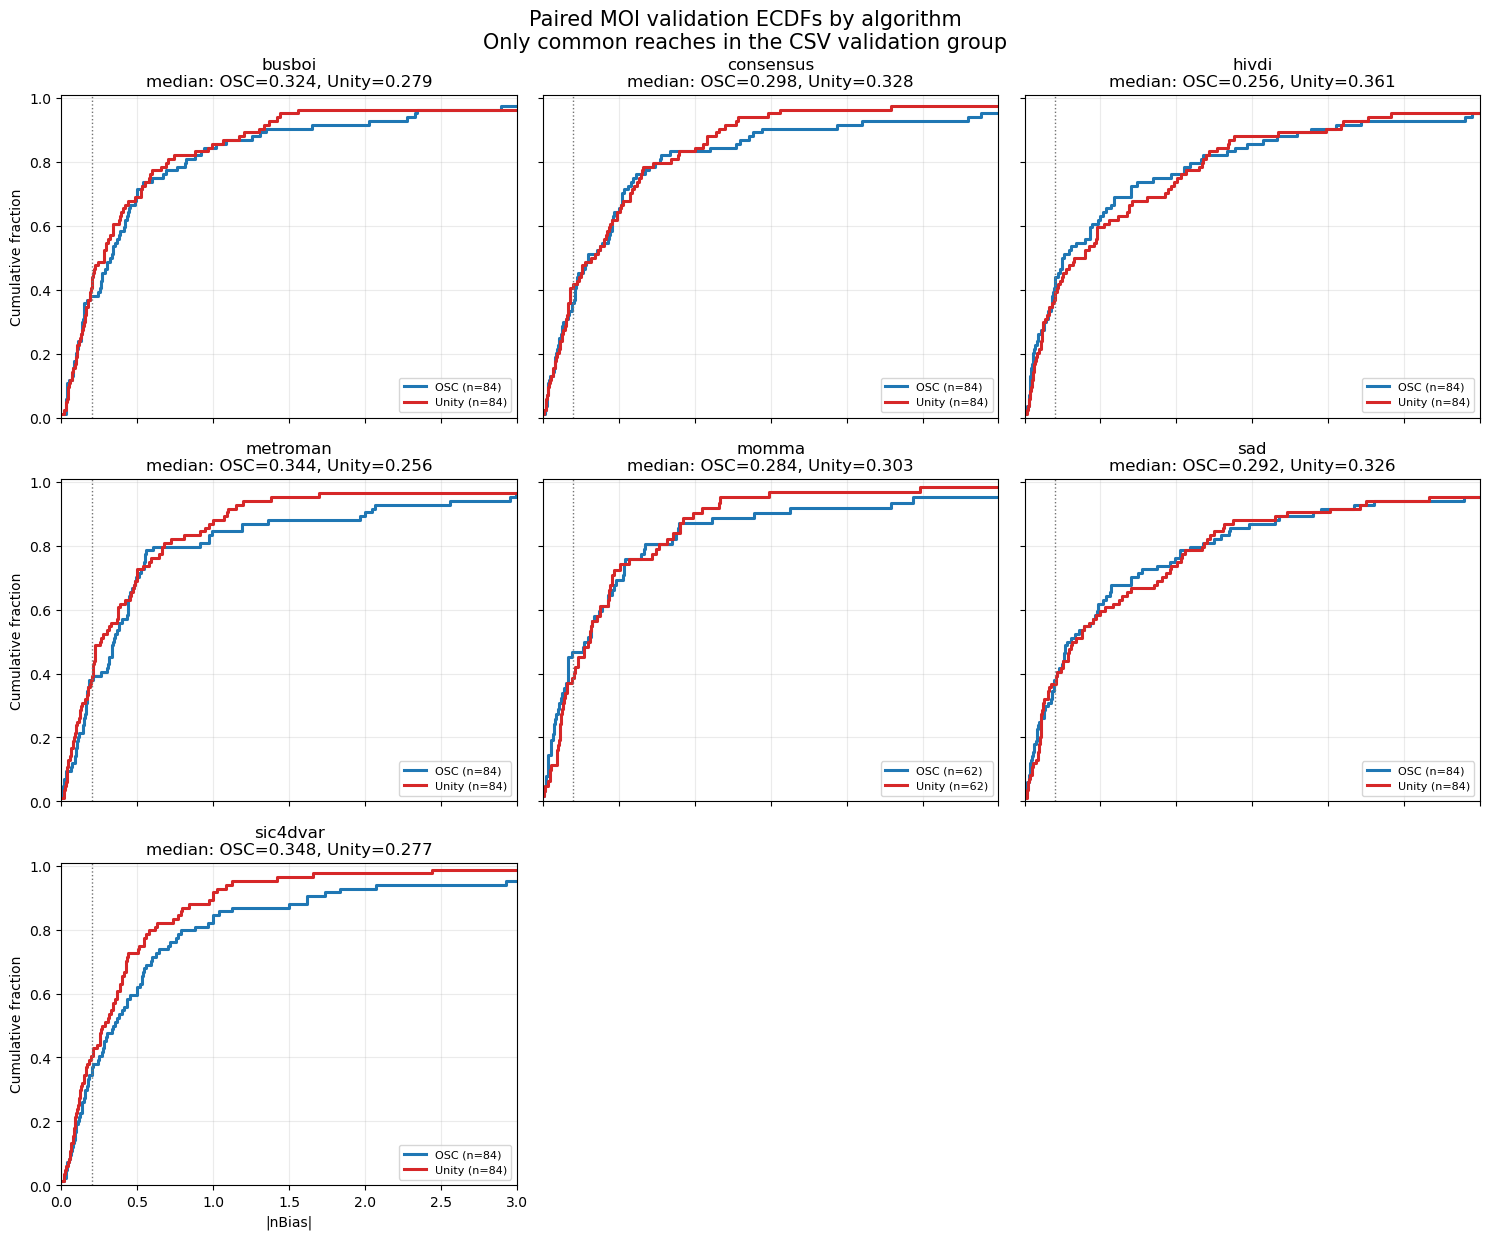

Saved: /Users/zhangyushan/Downloads/MOIcheck/osc_unity_validation_comparison/moi_abs_nbias_ecdf_paired_by_algorithm.png


In [12]:
ECDF_XMAX = 3.0

OSC_COLOR = "#1f77b4"
UNITY_COLOR = "#d62728"


def ecdf(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    values = np.sort(values)

    if values.size == 0:
        return np.array([]), np.array([])

    probabilities = (
        np.arange(1, values.size + 1)
        / values.size
    )
    return values, probabilities


def add_ecdf(
    ax,
    values,
    label,
    color,
    linestyle="-",
    linewidth=2.2,
):
    x, y = ecdf(values)

    if x.size:
        ax.step(
            x,
            y,
            where="post",
            label=f"{label} (n={len(x):,})",
            color=color,
            linestyle=linestyle,
            linewidth=linewidth,
        )


# Figure 1: unpaired coverage versus strictly paired comparison.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5.2),
    sharey=True,
)

add_ecdf(
    axes[0],
    osc_nbias["abs_nbias"],
    "OSC",
    OSC_COLOR,
)
add_ecdf(
    axes[0],
    unity_nbias["abs_nbias"],
    "Unity",
    UNITY_COLOR,
)

axes[0].set_title(
    "All available CSV-validation results\n"
    "(different reach populations)"
)

add_ecdf(
    axes[1],
    paired["abs_nbias_osc"],
    "OSC",
    OSC_COLOR,
)
add_ecdf(
    axes[1],
    paired["abs_nbias_unity"],
    "Unity",
    UNITY_COLOR,
)

axes[1].set_title(
    "Common reach–algorithm results\n"
    f"({paired['reach_id'].nunique():,} common reaches)"
)

for ax in axes:
    ax.axvline(
        0.20,
        color="0.45",
        linestyle=":",
        linewidth=1.2,
        label="20% |nBias|",
    )
    ax.set_xlim(0, ECDF_XMAX)
    ax.set_ylim(0, 1.01)
    ax.set_xlabel("Absolute normalized bias, |nBias|")
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Cumulative fraction")

fig.suptitle(
    "MOI validation accuracy: OSC vs Unity\n"
    "Curves farther left/up indicate better accuracy",
    fontsize=14,
)

fig.tight_layout()

overall_figure = (
    OUTPUT_DIR
    / "moi_abs_nbias_ecdf_all_vs_paired.png"
)

fig.savefig(
    overall_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", overall_figure)


# Figure 2: paired comparison separately for each algorithm.
preferred_order = [
    "busboi",
    "consensus",
    "hivdi",
    "metroman",
    "momma",
    "sad",
    "sic4dvar",
]

available_algorithms = set(paired["algorithm"])

algorithm_order = [
    algorithm
    for algorithm in preferred_order
    if algorithm in available_algorithms
]

algorithm_order.extend(
    sorted(available_algorithms - set(algorithm_order))
)

ncols = 3
nrows = math.ceil(len(algorithm_order) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 4.2 * nrows),
    sharex=True,
    sharey=True,
)

axes = np.asarray(axes).reshape(-1)

for ax, algorithm in zip(
    axes,
    algorithm_order,
):
    data = paired.loc[
        paired["algorithm"] == algorithm
    ]

    add_ecdf(
        ax,
        data["abs_nbias_osc"],
        "OSC",
        OSC_COLOR,
    )
    add_ecdf(
        ax,
        data["abs_nbias_unity"],
        "Unity",
        UNITY_COLOR,
    )

    osc_median = data["abs_nbias_osc"].median()
    unity_median = data["abs_nbias_unity"].median()

    ax.set_title(
        f"{algorithm}\n"
        f"median: OSC={osc_median:.3f}, "
        f"Unity={unity_median:.3f}"
    )

    ax.axvline(
        0.20,
        color="0.45",
        linestyle=":",
        linewidth=1,
    )

    ax.set_xlim(0, ECDF_XMAX)
    ax.set_ylim(0, 1.01)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

for ax in axes[len(algorithm_order):]:
    ax.set_visible(False)

for row_index in range(nrows):
    axes[row_index * ncols].set_ylabel(
        "Cumulative fraction"
    )

for ax in axes[-ncols:]:
    if ax.get_visible():
        ax.set_xlabel("|nBias|")

fig.suptitle(
    "Paired MOI validation ECDFs by algorithm\n"
    "Only common reaches in the CSV validation group",
    fontsize=15,
)

fig.tight_layout()

algorithm_figure = (
    OUTPUT_DIR
    / "moi_abs_nbias_ecdf_paired_by_algorithm.png"
)

fig.savefig(
    algorithm_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", algorithm_figure)